In [134]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [135]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [136]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [137]:
df = df.iloc[:, 1:]

In [138]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [139]:
from sklearn.preprocessing import LabelEncoder

In [140]:
encoder = LabelEncoder()

In [141]:
df['Species'] = encoder.fit_transform(df['Species'])

In [142]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [143]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [144]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

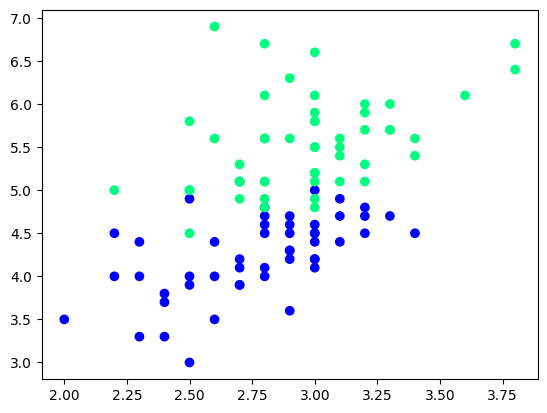

In [146]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')

In [147]:
# Taking only 10 rows for training
df = df.sample(100) # The data will be randomized
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)


In [148]:
df_train

,SepalWidthCm,PetalLengthCm,Species
79,2.6,3.5,1
59,2.7,3.9,1
60,2.0,3.5,1
125,3.2,6.0,2
149,3.0,5.1,2
91,3.0,4.6,1
71,2.8,4.0,1
148,3.4,5.4,2
64,2.9,3.6,1
110,3.2,5.1,2


In [149]:
df_val

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
117,3.8,6.7,2
144,3.3,5.7,2
142,2.7,5.1,2
54,2.8,4.6,1


In [150]:
df_test

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
95,3.0,4.2,1
62,2.2,4.0,1
57,2.4,3.3,1
135,3.0,6.1,2


In [151]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:, -1].values


In [152]:
X_test

array([[3.8, 6.4],
       [3.8, 6.7],
       [3.3, 5.7],
       [2.7, 5.1],
       [2.8, 4.6]])

In [153]:
y_test

array([2, 2, 2, 2, 1])

# Case 1: Bagging

## Bootstrapping

In [154]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
64,2.9,3.6,1
110,3.2,5.1,2
125,3.2,6.0,2
110,3.2,5.1,2
60,2.0,3.5,1
110,3.2,5.1,2
148,3.4,5.4,2
149,3.0,5.1,2


In [155]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [156]:
dt_bag1 = DecisionTreeClassifier()

In [159]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

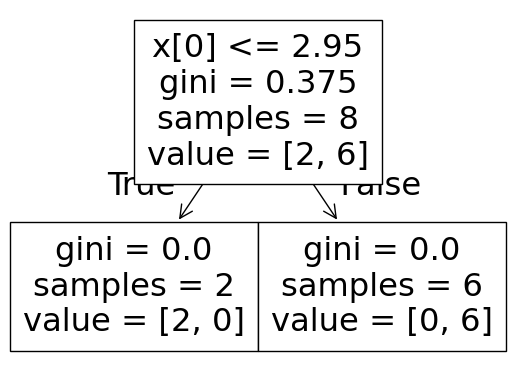

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


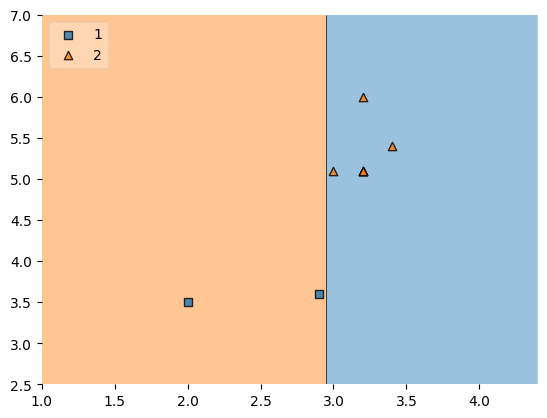

In [160]:
evaluate(dt_bag1,X,y)

In [161]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

# Fetch X and y 
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
64,2.9,3.6,1
125,3.2,6.0,2
91,3.0,4.6,1
91,3.0,4.6,1
125,3.2,6.0,2
59,2.7,3.9,1
91,3.0,4.6,1
91,3.0,4.6,1


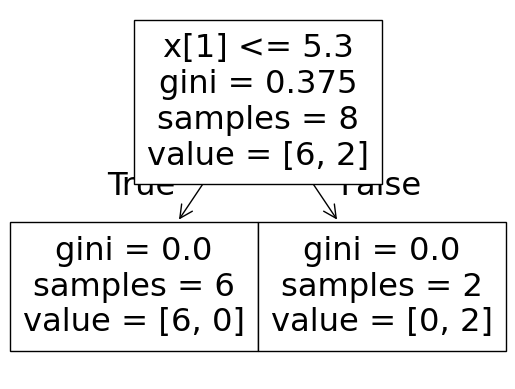

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


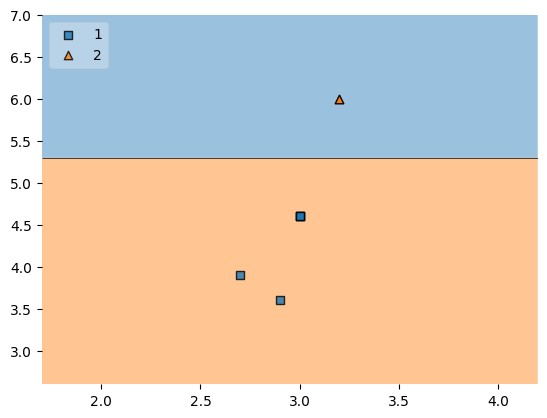

In [162]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

In [163]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:, -1]

# print df_bag
df_bag


,SepalWidthCm,PetalLengthCm,Species
125,3.2,6.0,2
125,3.2,6.0,2
64,2.9,3.6,1
64,2.9,3.6,1
148,3.4,5.4,2
60,2.0,3.5,1
148,3.4,5.4,2
60,2.0,3.5,1


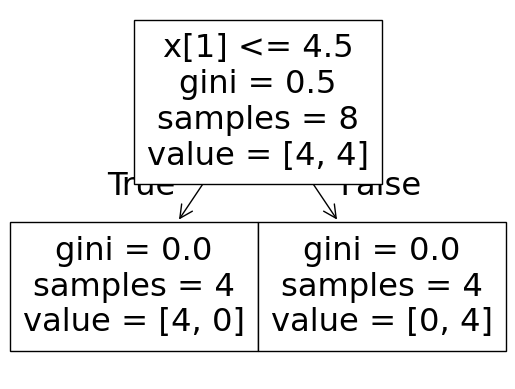

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


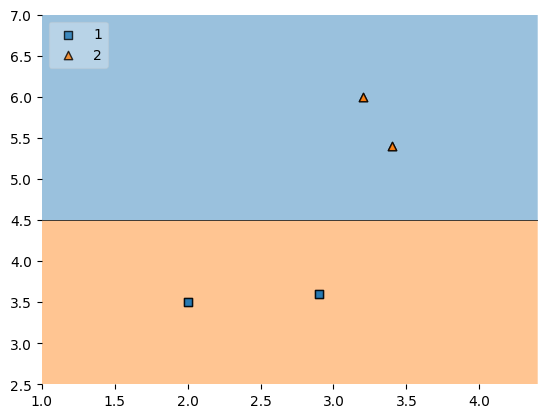

In [164]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

## Aggregation or Predict

In [165]:
df_test

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
95,3.0,4.2,1
62,2.2,4.0,1
57,2.4,3.3,1
135,3.0,6.1,2


In [168]:
print("Predictor 1", dt_bag1.predict(np.array([2.2, 5.0]).reshape(1,2)))
print("Predictor 2", dt_bag2.predict(np.array([2.2, 5.0]).reshape(1,2)))
print("Predictor 3", dt_bag3.predict(np.array([2.2, 5.0]).reshape(1,2)))


Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
